# ❤️ Heart Disease Prediction

In [13]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [14]:
# ============================================================
# CELL 2 — LOAD & CLEAN DATA
# ============================================================
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('heart.csv', names=columns)


df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)


df['ca']   = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])


df['target'] = df['target'].apply(lambda x: 1 if int(x) > 0 else 0)

print(f'Dataset shape : {df.shape}')
print(f'Target counts :\n{df["target"].value_counts()}')
df.head()

Dataset shape : (297, 14)
Target counts :
target
0    160
1    137
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


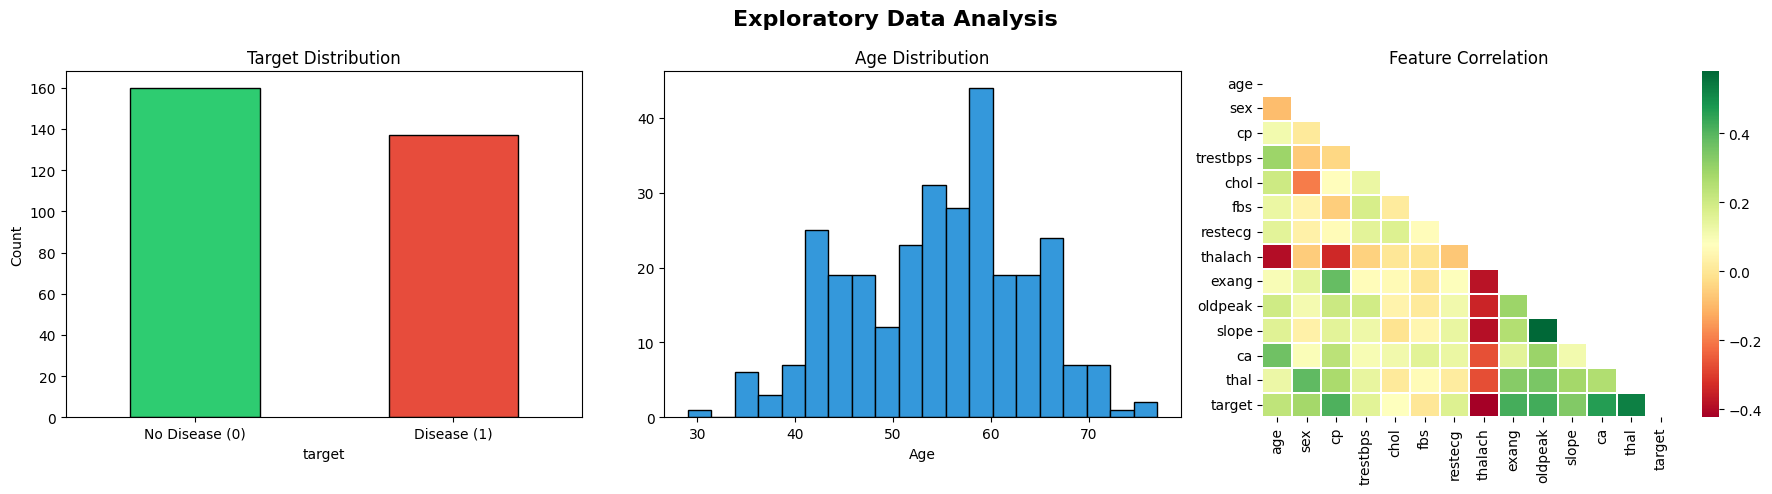

In [15]:
# ============================================================
# CELL 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')


df['target'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')


axes[1].hist(df['age'], bins=20, color='#3498db', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')


corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[2],
    cmap='RdYlGn', annot=False,
    linewidths=0.3
)
axes[2].set_title('Feature Correlation')

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# CELL 4 — FEATURE SELECTION
# ============================================================

FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach']
X = df[FEATURES]
y = df['target']

print(f'Features used : {len(FEATURES)}')
print(f'X shape       : {X.shape}')
print(f'y shape       : {y.shape}')

Features used : 6
X shape       : (297, 6)
y shape       : (297,)


In [17]:
# ============================================================
# CELL 5 — SPLIT & SCALE
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')

Train size : 237
Test size  : 60


In [18]:
# ============================================================
# CELL 6 — TRAIN 3 MODELS
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


lr_model = LogisticRegression(
    max_iter=1000,
    C=0.1,              
    random_state=42
)
lr_model.fit(X_train, y_train)
lr_cv  = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='accuracy')
lr_acc = accuracy_score(y_test, lr_model.predict(X_test))

print(f'Logistic Regression  — Test Acc: {lr_acc:.4f} | CV: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')


rf_model = RandomForestClassifier(
    n_estimators=200,   
    max_depth=6,        
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_cv  = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f'Random Forest        — Test Acc: {rf_acc:.4f} | CV: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')


gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05, 
    max_depth=4,
    subsample=0.8,      
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_cv  = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring='accuracy')
gb_acc = accuracy_score(y_test, gb_model.predict(X_test))

print(f'Gradient Boosting    — Test Acc: {gb_acc:.4f} | CV: {gb_cv.mean():.4f} ± {gb_cv.std():.4f}')

Logistic Regression  — Test Acc: 0.8333 | CV: 0.7723 ± 0.0487
Random Forest        — Test Acc: 0.7833 | CV: 0.7298 ± 0.0376
Gradient Boosting    — Test Acc: 0.7833 | CV: 0.7340 ± 0.0298


In [19]:
# ============================================================
# CELL 7 — CLASSIFICATION REPORTS
# ============================================================

for name, model in [
    ('Logistic Regression', lr_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model)
]:
    preds = model.predict(X_test)
    print('\n' + '='*50)
    print(f'  {name}')
    print('\n' + '='*50)
    print(classification_report(y_test, preds,
                                target_names=['No Disease', 'Disease']))


  Logistic Regression

              precision    recall  f1-score   support

  No Disease       0.79      0.94      0.86        32
     Disease       0.91      0.71      0.80        28

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60


  Random Forest

              precision    recall  f1-score   support

  No Disease       0.77      0.84      0.81        32
     Disease       0.80      0.71      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60


  Gradient Boosting

              precision    recall  f1-score   support

  No Disease       0.77      0.84      0.81        32
     Disease       0.80      0.71      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted a

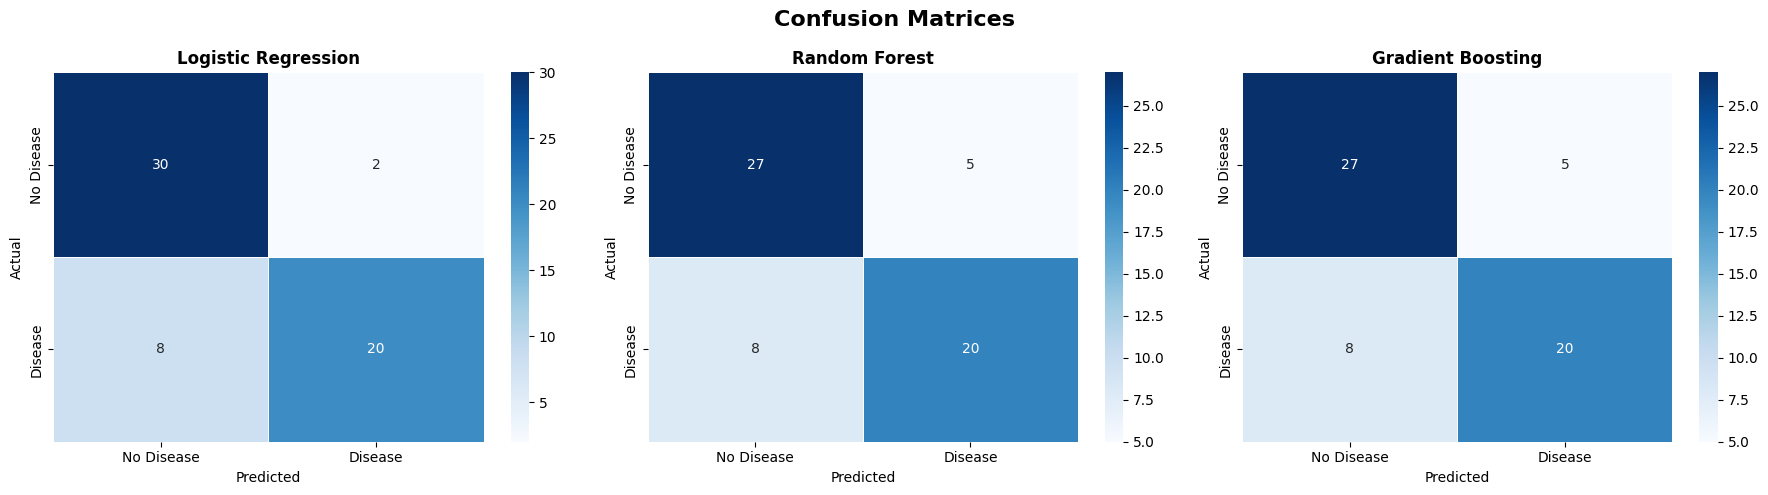

In [20]:
# ============================================================
# CELL 8 — CONFUSION MATRICES (للـ 3 موديلات)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (name, model) in zip(axes, [
    ('Logistic Regression', lr_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model)
]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

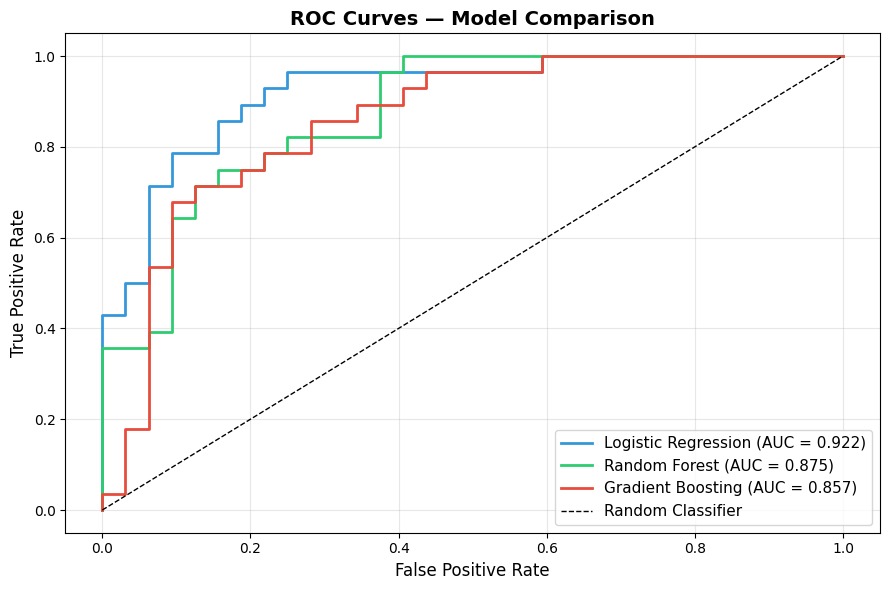

In [21]:
# ============================================================
# CELL 9 — ROC CURVES 
# ============================================================

plt.figure(figsize=(9, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, model), color in zip([
    ('Logistic Regression', lr_model),
    ('Random Forest',       rf_model),
    ('Gradient Boosting',   gb_model)
], colors):
    prob  = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

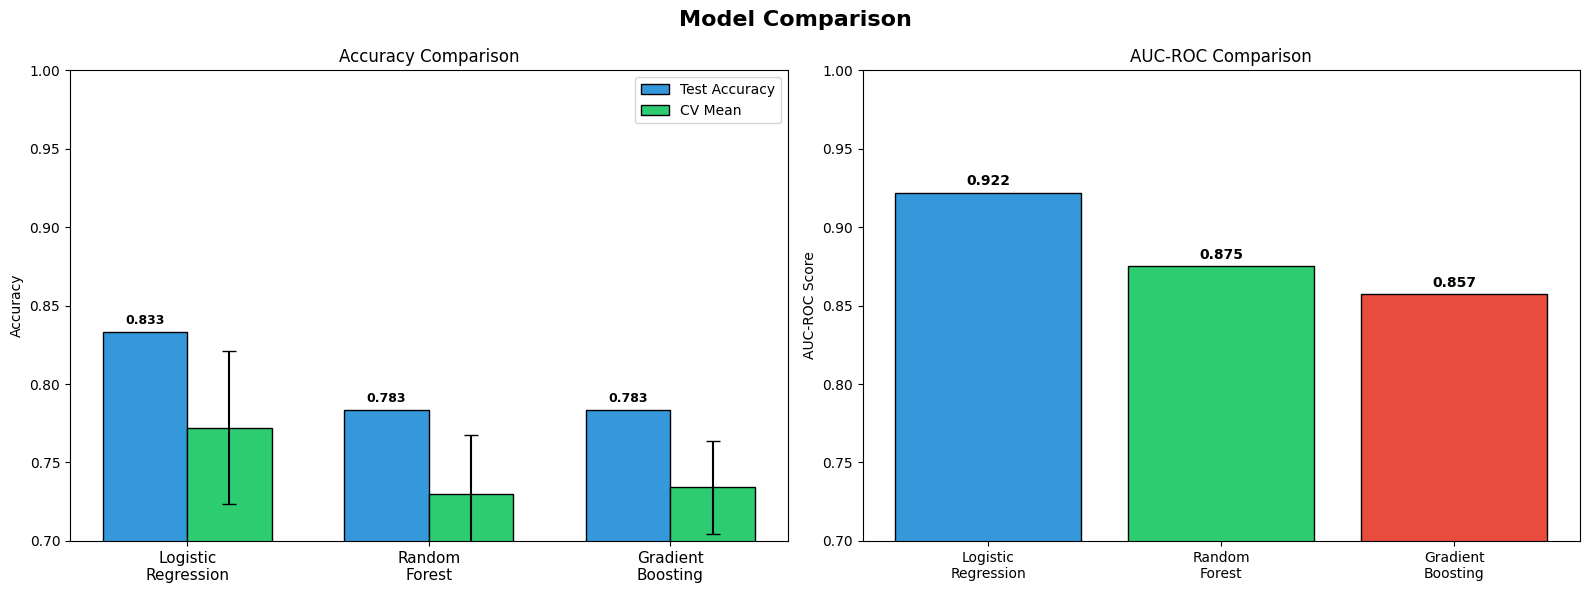

In [22]:
# ============================================================
# CELL 10 — VISUAL MODEL COMPARISON 
# ============================================================


model_names = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
test_accs   = [lr_acc,        rf_acc,        gb_acc]
cv_means    = [lr_cv.mean(),  rf_cv.mean(),  gb_cv.mean()]
cv_stds     = [lr_cv.std(),   rf_cv.std(),   gb_cv.std()]

x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')


bars1 = axes[0].bar(x - width/2, test_accs, width,
                    label='Test Accuracy', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, cv_means,  width,
                    label='CV Mean',       color='#2ecc71', edgecolor='black',
                    yerr=cv_stds, capsize=5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=11)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 1.0)
axes[0].legend()
axes[0].set_title('Accuracy Comparison')


for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )


aucs = [
    roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1]),
    roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
    roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1]),
]
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars_auc = axes[1].bar(model_names, aucs, color=colors, edgecolor='black')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_title('AUC-ROC Comparison')

for bar, val in zip(bars_auc, aucs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

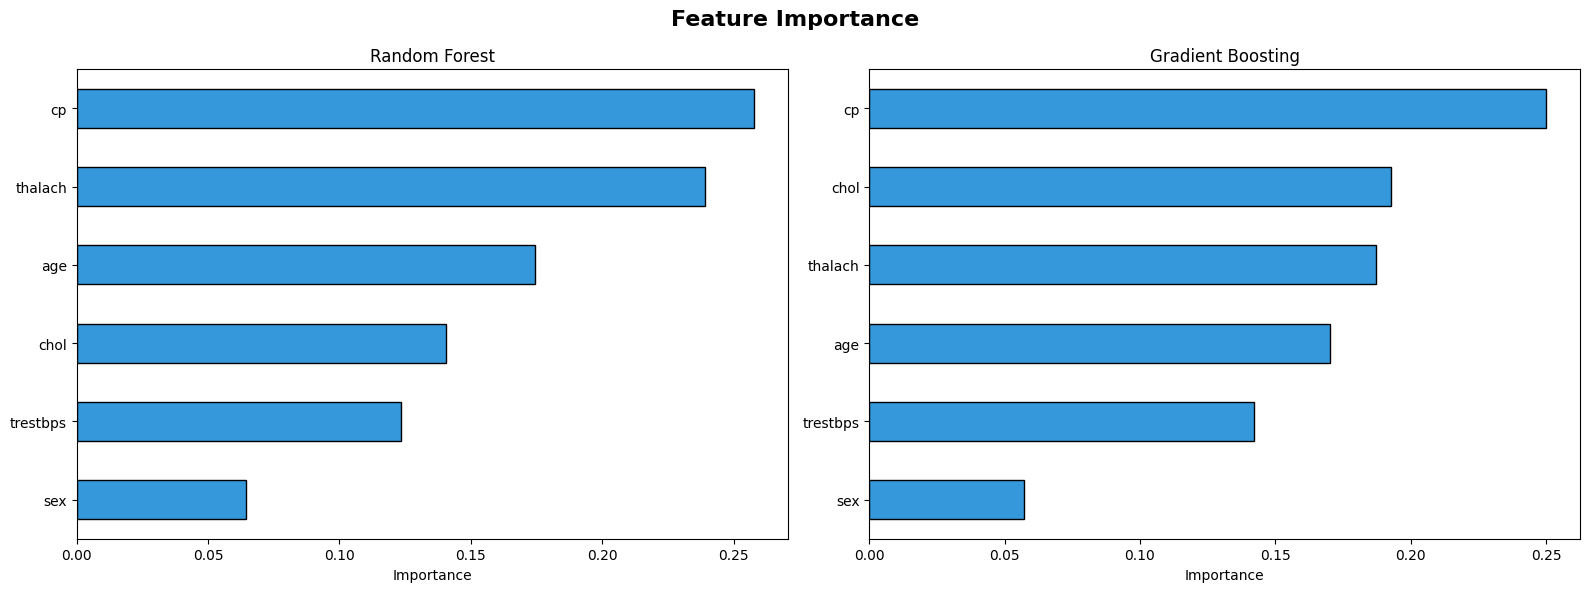

In [23]:
# ============================================================
# CELL 11 — FEATURE IMPORTANCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance', fontsize=16, fontweight='bold')

for ax, (name, model) in zip(axes, [
    ('Random Forest',     rf_model),
    ('Gradient Boosting', gb_model)
]):
    importances = pd.Series(
        model.feature_importances_, index=FEATURES
    ).sort_values(ascending=True)

    importances.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 12 — FINAL SAVE (FIXED)
# ============================================================
# NOTE: X_train and X_test were already scaled in Cell 5.
# We must go back to the ORIGINAL unscaled data to fit the
# final scaler correctly, so inference at runtime works properly.

# Step 1: Reload original unscaled splits from raw features
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 2: Fit a clean scaler on raw (unscaled) training data
final_scaler = StandardScaler()
X_train_final = final_scaler.fit_transform(X_train_raw)
X_test_final  = final_scaler.transform(X_test_raw)

# Step 3: Train final model on correctly scaled data
final_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, random_state=42
)
final_model.fit(X_train_final, y_train_raw)

acc = accuracy_score(y_test_raw, final_model.predict(X_test_final))
print(f"Final model accuracy: {acc:.4f}")

# Step 4: Print cp value range so app encoding is always correct
print(f"\ncp values in training data: {sorted(df['cp'].unique())}")
print(f"sex values in training data: {sorted(df['sex'].unique())}")
print(f"Feature order: {FEATURES}")

# Step 5: Save correctly
pickle.dump(final_model,  open('heart_model.pkl', 'wb'))
pickle.dump(final_scaler, open('scaler.pkl',      'wb'))

print("\n✅ heart_model.pkl saved — trained on correctly scaled data")
print("✅ scaler.pkl saved       — fitted on ORIGINAL unscaled data")
print("\n⚠️  Use the cp values printed above in your Streamlit app.")


Final model accuracy: 0.8000

cp values in training data: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
sex values in training data: [np.float64(0.0), np.float64(1.0)]
Feature order: ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalach']

✅ heart_model.pkl saved — trained on correctly scaled data
✅ scaler.pkl saved       — fitted on ORIGINAL unscaled data

⚠️  Use the cp values printed above in your Streamlit app.


In [25]:
# ============================================================
# CELL 13 — VERIFY: test a "healthy" profile
# ============================================================
import numpy as np

# A young female with good vitals — should predict NO disease
# cp=1 = Typical Angina (the lowest-risk type in this dataset)
test_profile = np.array([[30, 0, 1, 120, 170, 170]], dtype=float)
# columns:              age sex cp  bp   chol  thalach

test_scaled = final_scaler.transform(test_profile)
prob = final_model.predict_proba(test_scaled)[0][1]
pred = final_model.predict(test_scaled)[0]

print(f"Test profile  : Age=30, Female, cp=1 (Typical Angina), BP=120, Chol=170, MaxHR=170")
print(f"Prediction    : {'Disease' if pred == 1 else 'No Disease'}")
print(f"Probability   : {prob*100:.1f}%")
print()
print("If probability is still high (>50%), the dataset cp encoding")
print("may be 0-3 instead of 1-4. Check df['cp'].unique() output above.")


Test profile  : Age=30, Female, cp=1 (Typical Angina), BP=120, Chol=170, MaxHR=170
Prediction    : No Disease
Probability   : 1.6%

If probability is still high (>50%), the dataset cp encoding
may be 0-3 instead of 1-4. Check df['cp'].unique() output above.
